In [3]:
import matplotlib.pyplot as plt 
import pandas as pd 
import numpy as np
import scipy.stats as stats 

import csv
import datetime as dt

In [4]:
filename_StationA = "Station_A.txt"
filename_StationB = "Station_B.txt"
filename_StationC = "Station_C.txt"
filename_StationD = "Station_D.txt"

In [20]:
#Task1 : Select temperature values of the first three years from station A (Station_A.txt) and B (Station_B.txt).

#Define Station as variable (StationA => Selected_Station1)

selected_station1 = filename_StationC
selected_station2 = filename_StationD

#Number of years

y=6

with open(selected_station1, 'r') as infile, open('selected_station1.csv', 'w') as outfile:
        stripped = (line.strip() for line in infile)
        lines = (line.split(",") for line in stripped if line)
        writer = csv.writer(outfile)
        writer.writerows(lines)
#Select temperature values of the filtered years from First Station(Station_A.txt)

df_ST1 = pd.read_csv(selected_station1, parse_dates=True, index_col=0, engine='python', sep=";")
df_ST1.describe()

print(df_ST1)


df_ST1_FilterYears= df_ST1[df_ST1["date"]<19910000 + (y*10000)][["date","temperature"]]

print(df_ST1_FilterYears)


          date  temperature  humidity  precipitation
0     19900101         -3.4      94.0            0.0
1     19900102         -2.7      94.0            0.0
2     19900103         -1.6      95.0            0.0
3     19900104         -2.6      89.0            0.0
4     19900105          1.6      84.0            1.4
5     19900106          1.7      96.0            0.0
6     19900107          0.1      91.0            0.0
7     19900108          1.2      93.0            0.0
8     19900109         -0.3      96.0            0.1
9     19900110         -0.7      94.0            0.0
10    19900111         -1.8      92.0            0.0
11    19900112         -3.7      94.0            0.0
12    19900113         -0.8      85.0            0.0
13    19900114          1.9      79.0            0.3
14    19900115          4.0      78.0            1.4
15    19900116          9.0      75.0            0.0
16    19900117          8.1      85.0            6.9
17    19900118          2.6      81.0         

In [22]:
#Select temperature values of the filtered years from Second Station (Station_B.txt).


with open(selected_station2, 'r') as infile, open('selected_station2.csv', 'w') as outfile:
        stripped = (line.strip() for line in infile)
        lines = (line.split(",") for line in stripped if line)
        writer = csv.writer(outfile)
        writer.writerows(lines)
        
df_ST2 = pd.read_csv(selected_station2, parse_dates=True, index_col=0, engine='python', sep=";")
df_ST2.describe()

#Filter for years 

df_ST2_FilterYears= df_ST2[df_ST2["date"]<19910000 + (y*10000)][["date","temperature"]]

print(df_ST2_FilterYears)


          date  temperature
0     19900101         -1.0
1     19900102          0.1
2     19900103          1.2
3     19900104          1.1
4     19900105         -1.7
5     19900106         -4.1
6     19900107         -1.2
7     19900108         -0.3
8     19900109         -0.6
9     19900110          0.9
10    19900111          0.2
11    19900112          1.1
12    19900113         -0.3
13    19900114         -2.2
14    19900115         -3.5
15    19900116          4.0
16    19900117         -0.2
17    19900118         -4.9
18    19900119         -2.2
19    19900120         -0.9
20    19900121          2.3
21    19900122          2.4
22    19900123          2.6
23    19900124         -1.4
24    19900125          1.2
25    19900126         -4.9
26    19900127         -0.7
27    19900128         -2.0
28    19900129         -1.8
29    19900130         -1.6
...        ...          ...
2161  19951202         -0.6
2162  19951203         -2.8
2163  19951204         -7.9
2164  19951205      

In [23]:
#Write the values of both stations into a single text file (you can choose a file name yourself)
#Name: Selected Staion 1 and 2 FilteredYears

df_ST1ST2 = pd.concat([df_ST1_FilterYears, df_ST2_FilterYears], axis=1)
df_ST1ST2.to_csv('Selected Staion 1 and 2 FilteredYears.txt', index=False, sep=' ', header=None)

In [24]:
#Task2: Find potential missing data (marked as -999) and replace them with NaN values (np.nan).

#Potential missing data selected in Station1 and Station2 values 
df_ST1ST2.replace('-999', np.NaN)


,date,temperature,date,temperature
0,19900101,-3.4,19900101,-1.0
1,19900102,-2.7,19900102,0.1
2,19900103,-1.6,19900103,1.2
3,19900104,-2.6,19900104,1.1
4,19900105,1.6,19900105,-1.7
5,19900106,1.7,19900106,-4.1
6,19900107,0.1,19900107,-1.2
7,19900108,1.2,19900108,-0.3
8,19900109,-0.3,19900109,-0.6
9,19900110,-0.7,19900110,0.9


In [25]:
#Task 3: Calculate the monthly maxima for First (Station A) and Second Station (Station B)
#and plot them as two time series in a single graph
#which you save in the folder of your Python script.This graph must be in publication quality (labels, readability, label size, etc.).
#Name of saved plot: plot_1

df_ST1_FilterYears["date"] =  pd.to_datetime(df_ST1_FilterYears["date"], format='%Y%m%d')
df_ST1_FilterYears.head()
monthly_max_ST1 = df_ST1_FilterYears.groupby(df_ST1_FilterYears["date"].dt.month).temperature.max()

df_ST2_FilterYears["date"] =  pd.to_datetime(df_ST2_FilterYears["date"], format='%Y%m%d')
df_ST2_FilterYears.head()
monthly_max_ST2= df_ST2_FilterYears.groupby(df_ST2_FilterYears["date"].dt.month).temperature.max() 



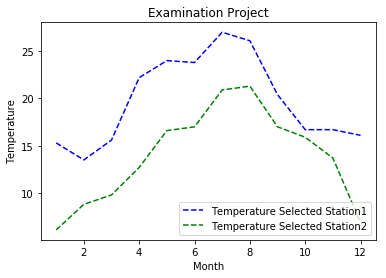

In [26]:
fig, ax = plt.subplots()
ax.plot(monthly_max_ST1, "--", color="b")
ax.plot(monthly_max_ST2, "--", color="g")

ax.set_title('Examination Project')
ax.set_ylabel('Temperature')
ax.set_xlabel('Month')
plt.legend(['Temperature Selected Station1','Temperature Selected Station2'],loc=4)
plt.savefig(r'plot_1.png')
plt.show()

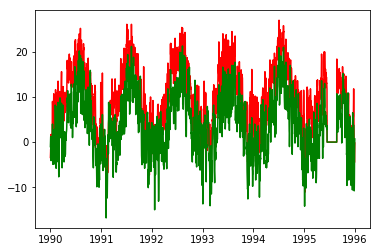

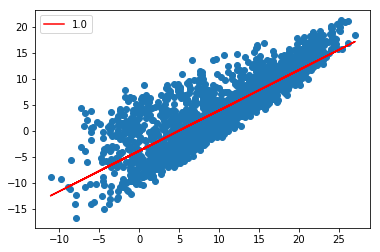

In [27]:
#Task4: Generate a scatter plot of the daily values of both stations (A and B) including a linear regression line.

plt.close()

#Without NaN values for both stations for the calculations

df_ST1_FilterYearsclean= df_ST1_FilterYears.dropna(how='any')

df_ST1_FilterYearsclean.loc[df_ST1_FilterYearsclean.temperature <(-100), "temperature"] = 0

df_ST2_FilterYearsclean= df_ST2_FilterYears.dropna(how='any')

df_ST2_FilterYearsclean.loc[df_ST2_FilterYearsclean.temperature <(-100), "temperature"] = 0

plt.plot_date(df_ST1_FilterYearsclean["date"], df_ST1_FilterYearsclean["temperature"],'r')
plt.plot_date(df_ST2_FilterYearsclean["date"], df_ST2_FilterYearsclean["temperature"],'g')

plt.show()

plt.close()

#Create Scatter plot 

X = df_ST1_FilterYearsclean["temperature"].as_matrix() 


Y = df_ST2_FilterYearsclean["temperature"].as_matrix() 

#Write the  on the regression line of the plot 

a,b=np.polyfit(X,Y,1)
y_pred=a*X+b


plt.scatter(X, Y)
plt.plot(X,y_pred,'r')

#Write the Pearson correlation coefficient on the regression line of the plot

plt.legend([str(stats.pearsonr(X, y_pred)[0])],loc=2)
plt.show()




date
1     0.458871
2    -0.376991
3     0.014516
4     0.665833
5     0.461290
6     0.670000
7     0.407258
8    -0.297581
9    -0.193333
10    0.077419
11    0.481667
12    0.351613
Name: temperature, dtype: float64


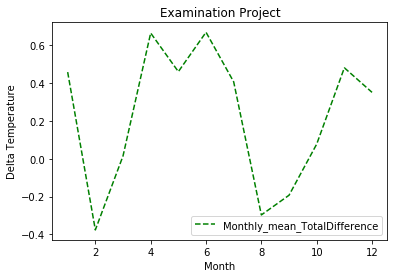

Month: 6
Largest Difference: 0.6700000000000053


In [18]:
#Task5: Calculate the differences between monthly means of two stations and plot them in a figure

monthly_mean_ST1 = df_ST1_FilterYearsclean.groupby(df_ST1_FilterYearsclean["date"].dt.month).temperature.mean()


monthly_mean_ST2 = df_ST2_FilterYearsclean.groupby(df_ST2_FilterYearsclean["date"].dt.month).temperature.mean()


monthly_mean_Total = monthly_mean_ST1 - monthly_mean_ST2 

print (monthly_mean_Total)
fig, ax = plt.subplots()
ax.plot(monthly_mean_Total, "--", color="g")

#Save in the folder of your Python script (labels, readability, label size, etc.)
#Name of the file: plot_2
ax.set_title('Examination Project')
ax.set_ylabel('Delta Temperature')
ax.set_xlabel('Month')
plt.legend(['Monthly_mean_TotalDifference'],loc=4)
plt.savefig(r'plot_2.png')
plt.show()

#Task6: Find the month for which the differences calculated in 5. are maximum
#and print the month and corresponding year together with the largest difference.

monthly_mean_Total.max()

g = monthly_mean_Total.index.max()
l = monthly_mean_Total.max()
max_month=monthly_mean_Total[monthly_mean_Total.iloc[:]==monthly_mean_Total.max()].index[0]
print("Month: {}".format(max_month))
print("Largest Difference: {}".format(l))


In [28]:
#Put this task into a function of a separate Python file
df1 = df_ST1_FilterYearsclean.loc[df_ST1_FilterYearsclean.date.dt.month==12]
def calc_max(frame1,frame2):
    monthly_mean_ST1 = frame1.groupby(frame1["date"].dt.month).temperature.mean()
    monthly_mean_ST2 = frame2.groupby(frame2["date"].dt.month).temperature.mean()
    monthly_mean_Total = monthly_mean_ST1 - monthly_mean_ST2 
    monthly_mean_difference=monthly_mean_Total.max()
    max_month=monthly_mean_Total[monthly_mean_Total.iloc[:]==monthly_mean_Total.max()].index[0]
    max_month_difference = monthly_mean_Total.max(axis = 0)
    year_max_month_difference= frame1.loc[frame1.date.dt.month==max_month,"temperature"]-frame2.loc[frame2.date.dt.month==max_month,"temperature"]
    max_year_index=year_max_month_difference[year_max_month_difference.iloc[:]==year_max_month_difference.max()].index[0]
    max_year=frame1.loc[max_year_index,"date"]
    print("month: {},year: {}, difference: {}".format(max_year.month,max_year.year,max_month_difference))
   

calc_max(df_ST1_FilterYearsclean,df_ST2_FilterYearsclean)

month: 4,year: 1992, difference: 8.175


In [ ]:
#Make the stations and the number of years you choose variable, such that the script still works,
#if the variables are changed. 
#Check it for 6 years using data of station C and D.
#->Change the Station Name and the year at the top of this file 